# GNN training diagnostics — 900-epoch study + clean 1500-epoch rerun

> **Exploratory training diagnostic.** The optimization curves are useful, but absolute graph metrics inherit the provisional split/MP protocol and require rerun. See `README.md`.

Источник: `results/graph/full_full/legacy/pre_v5/provisional_and_900_pilot/history/gnn_signed_q95_inductive_molecule_fold1.csv`  
Конфигурация: GraphSAGE signed · q95 · inductive_molecule · fold 1 · seed 42

**Ключевые эпохи:**
- best val AUPRC → epoch 245 (downstream probe: AUPRC ~0.667)
- best test AUPRC (диагностика) → epoch 543
- final → epoch 900

Downstream XGBoost probe на 900-эп энкодере: AUROC 0.807 (+0.024 vs 300-эп).

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "results/graph/full_full/legacy/pre_v5/provisional_and_900_pilot/history/gnn_signed_q95_inductive_molecule_fold1.csv")
print(f"epochs: {len(df)}  |  columns: {list(df.columns)}")

best_val_auprc_ep  = int(df["val_AUPRC"].idxmax())  + 1
best_test_auprc_ep = int(df["test_AUPRC"].idxmax()) + 1
print(f"Best val  AUPRC = {df['val_AUPRC'].max():.4f}  @ epoch {best_val_auprc_ep}")
print(f"Best test AUPRC = {df['test_AUPRC'].max():.4f}  @ epoch {best_test_auprc_ep}  (diagnostic only)")

epochs: 900  |  columns: ['epoch', 'train_loss', 'val_AUROC', 'val_AUPRC', 'val_MCC', 'val_F1', 'val_precision', 'val_recall', 'test_AUROC', 'test_AUPRC', 'test_MCC', 'test_F1', 'test_precision', 'test_recall']
Best val  AUPRC = 0.7983  @ epoch 245
Best test AUPRC = 0.5947  @ epoch 543  (diagnostic only)


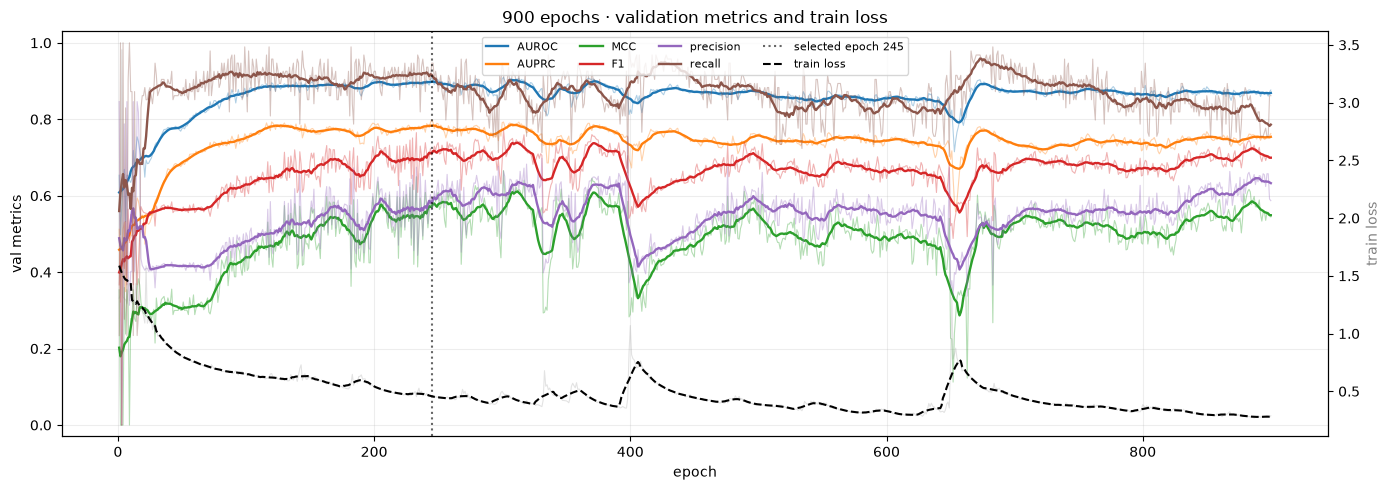

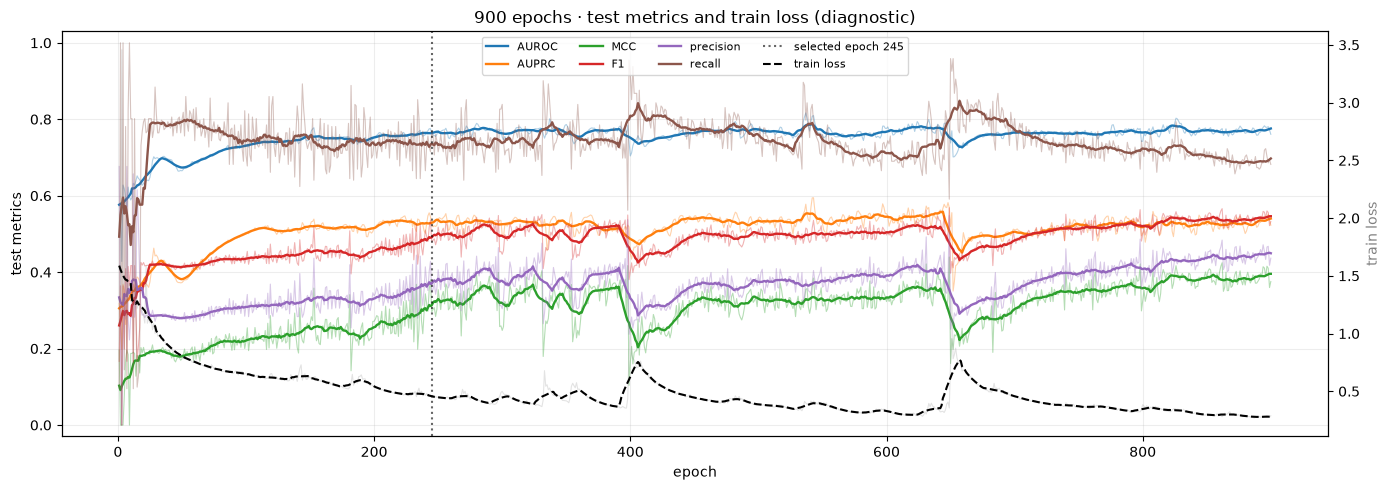

In [11]:
METRIC_NAMES = ["AUROC", "AUPRC", "MCC", "F1", "precision", "recall"]
METRIC_COLORS = dict(zip(METRIC_NAMES, plt.cm.tab10.colors[:len(METRIC_NAMES)]))

def plot_metric_canvas(frame, prefix, title, best_epoch, smooth=15, final_metrics=None,
                       raw_alpha=.10, raw_lw=.6, loss_raw_alpha=.08):
    epochs = frame["epoch"].to_numpy()
    fig, metric_ax = plt.subplots(figsize=(14, 5))

    if prefix is not None:
        for name in METRIC_NAMES:
            column = f"{prefix}_{name}"
            raw = frame[column]
            trend = raw.rolling(smooth, center=True, min_periods=1).mean()
            metric_ax.plot(epochs, raw, color=METRIC_COLORS[name], alpha=raw_alpha, lw=raw_lw)
            metric_ax.plot(epochs, trend, color=METRIC_COLORS[name], lw=1.7, label=name)
    else:
        for name in METRIC_NAMES:
            metric_ax.scatter(best_epoch, final_metrics[name], s=45,
                              color=METRIC_COLORS[name], label=f"{name} (final only)")
        metric_ax.text(.99, .03, "No epoch-wise test history; one evaluation after val selection",
                       transform=metric_ax.transAxes, ha="right", fontsize=9)

    metric_ax.set_ylim(-.03, 1.03)
    metric_ax.set_ylabel(f"{prefix or 'test'} metrics")
    metric_ax.set_xlabel("epoch")
    metric_ax.axvline(best_epoch, color="black", ls=":", alpha=.6,
                       label=f"selected epoch {best_epoch}")
    metric_ax.grid(alpha=.22)

    loss_ax = metric_ax.twinx()
    loss = frame["train_loss"]
    loss_trend = loss.rolling(smooth, center=True, min_periods=1).mean()
    loss_ax.plot(epochs, loss, color="gray", alpha=loss_raw_alpha, lw=raw_lw)
    loss_ax.plot(epochs, loss_trend, color="black", ls="--", lw=1.5, label="train loss")
    loss_ax.set_ylabel("train loss", color="gray")

    lines1, labels1 = metric_ax.get_legend_handles_labels()
    lines2, labels2 = loss_ax.get_legend_handles_labels()
    metric_ax.legend(lines1 + lines2, labels1 + labels2, ncol=4, fontsize=8, loc="upper center")
    metric_ax.set_title(title)
    plt.tight_layout()
    plt.show()

# 900-run canvases: raw (unsmoothed) lines drawn brighter to show epoch-to-epoch noise.
plot_metric_canvas(df, "val", "900 epochs · validation metrics and train loss",
                   best_val_auprc_ep, smooth=15, raw_alpha=.35, raw_lw=.8, loss_raw_alpha=.22)
plot_metric_canvas(df, "test", "900 epochs · test metrics and train loss (diagnostic)",
                   best_val_auprc_ep, smooth=15, raw_alpha=.35, raw_lw=.8, loss_raw_alpha=.22)

In [12]:
# Intentionally empty: loss is included in both canvases above.

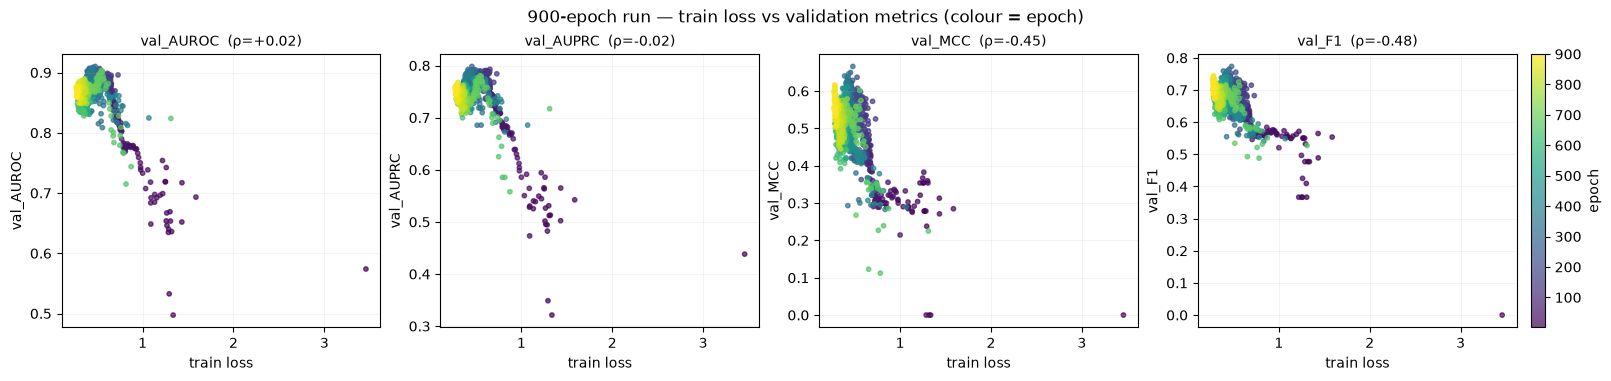

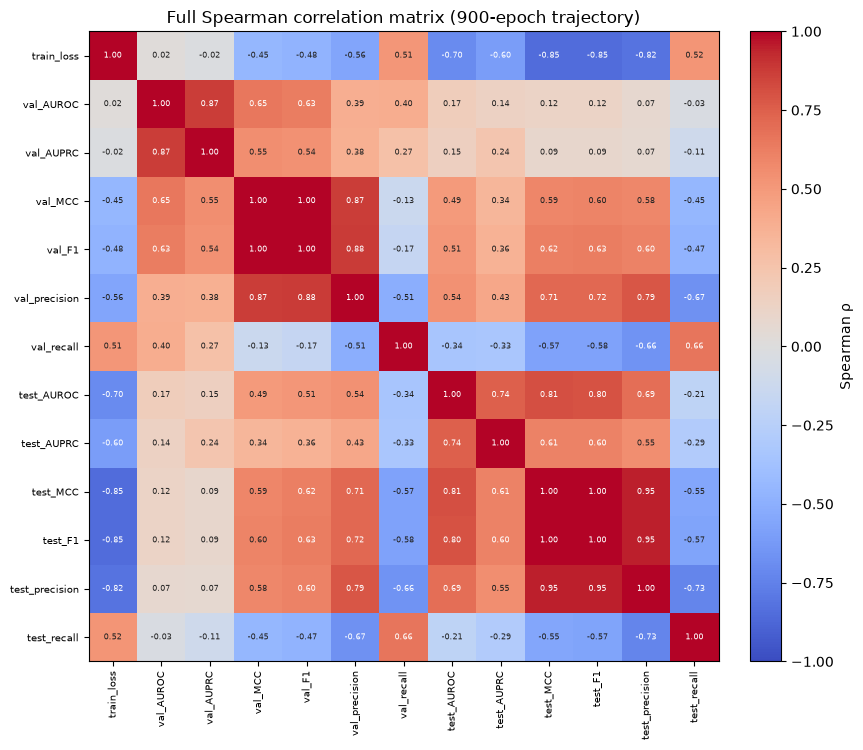

In [13]:
# Correlation structure over the 900-epoch trajectory (each point = one epoch).
# (a) loss-vs-metric clouds, coloured by epoch; (b) full Spearman correlation matrix.
FIGDIR = ROOT / "notebooks/figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

CLOUD_METRICS = ["val_AUROC", "val_AUPRC", "val_MCC", "val_F1"]
fig, axes = plt.subplots(1, len(CLOUD_METRICS), figsize=(4 * len(CLOUD_METRICS), 3.7),
                         constrained_layout=True)
for ax, m in zip(axes, CLOUD_METRICS):
    sc = ax.scatter(df["train_loss"], df[m], c=df["epoch"], cmap="viridis", s=10, alpha=.7)
    rho = df["train_loss"].corr(df[m], method="spearman")
    ax.set_xlabel("train loss"); ax.set_ylabel(m)
    ax.set_title(f"{m}  (ρ={rho:+.2f})", fontsize=10); ax.grid(alpha=.15)
cb = fig.colorbar(sc, ax=axes, fraction=.02, pad=.01); cb.set_label("epoch")
fig.suptitle("900-epoch run — train loss vs validation metrics (colour = epoch)")
plt.savefig(FIGDIR / "diag_loss_vs_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Full Spearman correlation matrix of every tracked quantity (loss + val + test).
cols = [c for c in df.columns if c != "epoch"]
corr = df[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7.6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)   # diverging, neutral at 0
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5,
                color="white" if abs(v) > .6 else "#222")
cb = fig.colorbar(im, fraction=.046, pad=.04); cb.set_label("Spearman ρ")
ax.set_title("Full Spearman correlation matrix (900-epoch trajectory)")
plt.tight_layout()
plt.savefig(FIGDIR / "diag_corr_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Intentionally empty: key-epoch control table was removed.

## Выводы

- Val метрики **немонотонны**: есть провалы с последующим восстановлением — ранняя остановка по декодеру 
  на epoch 300 обрывает полезное дообучение энкодера.
- Best val AUPRC ≠ best epoch для downstream XGBoost probe: 900-эп энкодер даёт лучший probe 
  даже при val AUPRC ниже пика.
- Val ↔ Test Spearman ρ ~0.76–0.80: грубая корреляция есть, но точечный выбор эпохи по val AUPRC 
  не оптимален для probe.

**Рекомендация:** сохранять энкодер-чекпоинты (каждые 50–100 эпох), выбирать эпоху по 
**val probe AUPRC** (XGBoost на train/val), тест трогать только один раз.

## All 1500-epoch runs — combined training curves

Every clean 1500-epoch run on the stable recipe (`results/graph/full_full/legacy/pre_v5/rerun_v3` + `results/graph/full_full/legacy/pre_v5/sweep_v3`),
overlaid so training dynamics can be compared at a glance. Five panels: **train loss**, **AUROC**,
**AUPRC**, **MCC**, **F1** (validation, lightly smoothed). Colour = architecture (GNN / GAT),
line style = regime (solid = transductive, dashed = inductive_molecule). The collapsed v2 runs are
intentionally excluded — they belong to the superseded default-recipe sweep.

26 runs @1500 epochs  |  GNN=14  GAT=12


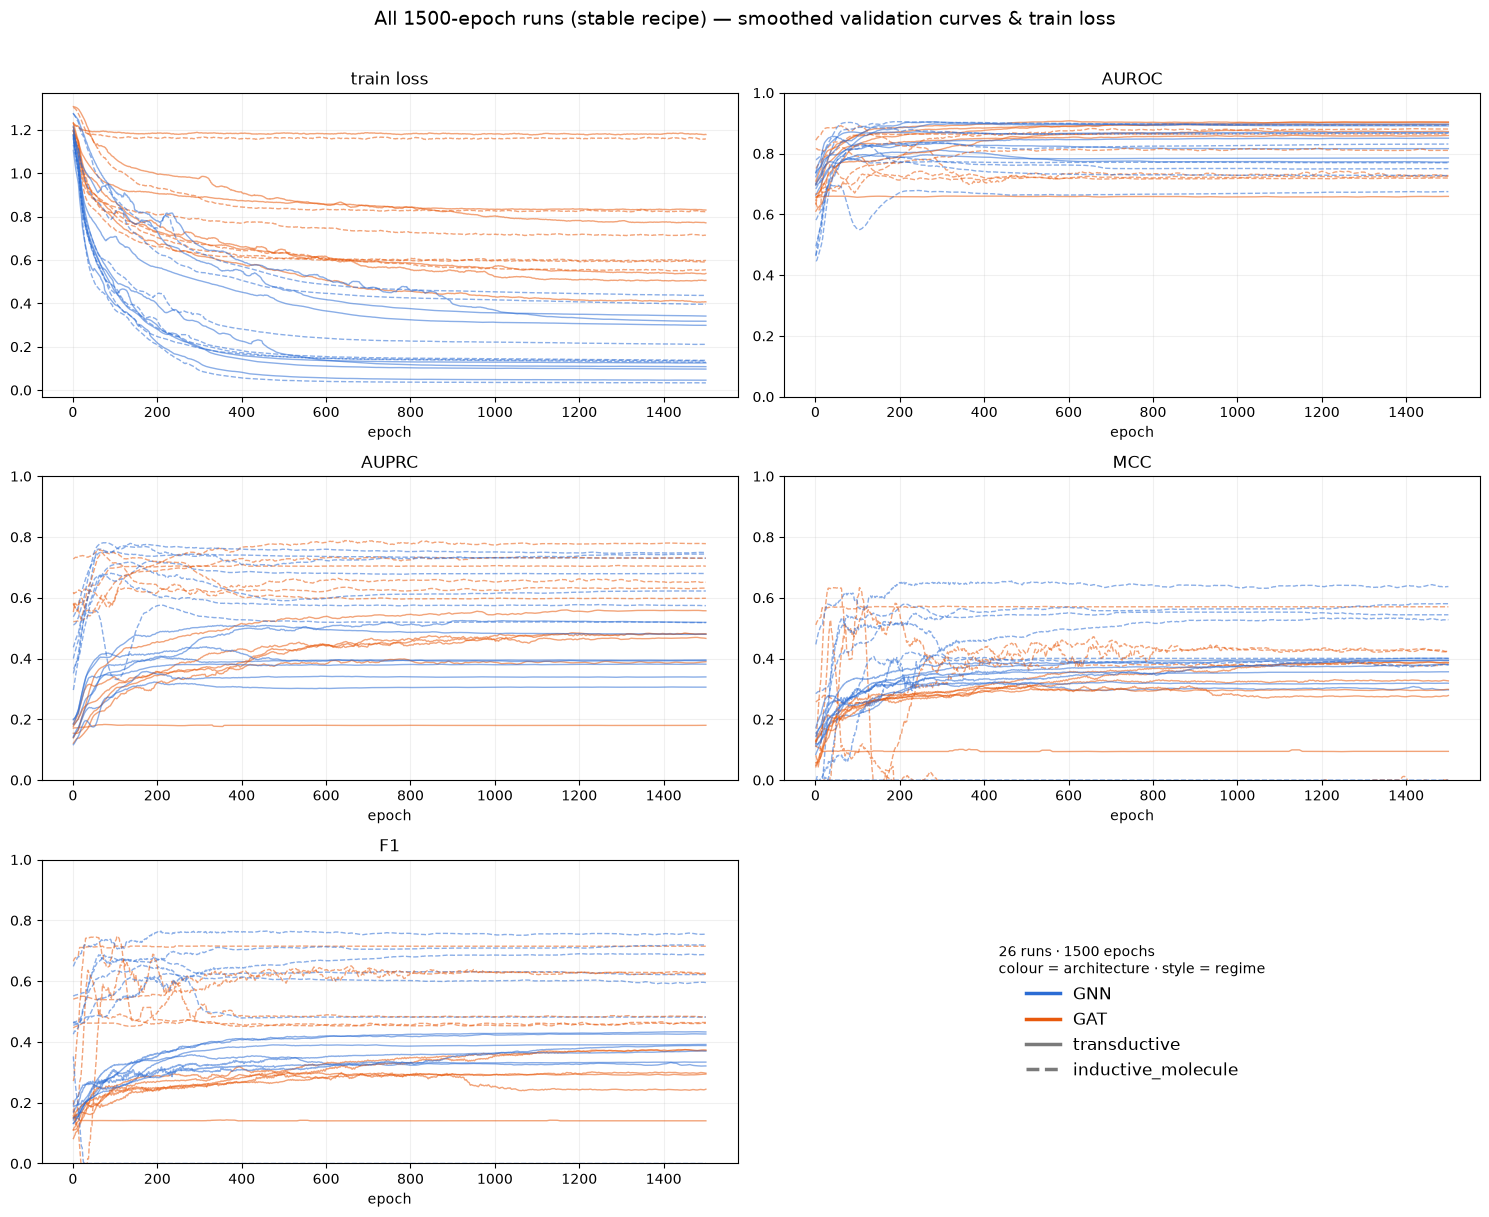

In [15]:
from matplotlib.lines import Line2D

# All clean 1500-epoch histories (stable recipe). v2 = collapsed default recipe, excluded.
ALL_1500_DIRS = [ROOT / "results/graph/full_full/legacy/pre_v5/rerun_v3/full_full/history",
                 ROOT / "results/graph/full_full/legacy/pre_v5/sweep_v3/full_full/history"]
PANELS = [("train_loss", "train loss"), ("val_AUROC", "AUROC"),
          ("val_AUPRC", "AUPRC"), ("val_MCC", "MCC"), ("val_F1", "F1")]
ARCH_C = {"gnn": "#2B6CD4", "gat": "#E8590C"}   # CVD-safe pair (validated)
REGIME_LS = {"transductive": "-", "inductive_molecule": "--"}
SMOOTH = 25

all_runs = []
for d in ALL_1500_DIRS:
    for csv in sorted(d.glob("*_fold1.csv")):
        frame = pd.read_csv(csv)
        if len(frame) < 1000:            # only the full 1500-epoch runs
            continue
        name = csv.stem
        arch = "gnn" if name.startswith("gnn") else "gat"
        regime = "inductive_molecule" if "inductive_molecule" in name else "transductive"
        all_runs.append((name, arch, regime, frame))

n_gnn = sum(a == "gnn" for _, a, _, _ in all_runs)
print(f"{len(all_runs)} runs @1500 epochs  |  GNN={n_gnn}  GAT={len(all_runs) - n_gnn}")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()
for ax, (col, label) in zip(axes, PANELS):
    for _, arch, regime, frame in all_runs:
        if col not in frame:
            continue
        trend = frame[col].rolling(SMOOTH, center=True, min_periods=1).mean()
        ax.plot(frame["epoch"], trend, color=ARCH_C[arch],
                ls=REGIME_LS[regime], lw=1.0, alpha=0.55)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.18)
    if col != "train_loss":
        ax.set_ylim(0, 1)

# 6th slot: legend only (color = arch, style = regime — identity never colour-alone)
axes[-1].axis("off")
legend_handles = [
    Line2D([0], [0], color=ARCH_C["gnn"], lw=2.5, label="GNN"),
    Line2D([0], [0], color=ARCH_C["gat"], lw=2.5, label="GAT"),
    Line2D([0], [0], color="#7a7a7a", lw=2.5, ls="-", label="transductive"),
    Line2D([0], [0], color="#7a7a7a", lw=2.5, ls="--", label="inductive_molecule"),
]
axes[-1].legend(handles=legend_handles, loc="center", fontsize=12, frameon=False,
                title=f"{len(all_runs)} runs · 1500 epochs\ncolour = architecture · style = regime")

fig.suptitle("All 1500-epoch runs (stable recipe) — smoothed validation curves & train loss",
             fontsize=14, y=1.01)
plt.tight_layout()
(ROOT / "notebooks/figures").mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT / "notebooks/figures/diag_all_1500_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Test-metric correlation across runs

One row per run = its final **test** metrics (XGBoost probe on `best_state`, from each checkpoint's
`test_scores`), pooled over the same 26 clean 1500-epoch runs. The Spearman matrix below shows which
test metrics move together across the run population (not over epochs).

In [16]:
import torch
try:
    metrics  # from orbind.dataset, imported as binding_metrics earlier
except NameError:
    from orbind.dataset import metrics as binding_metrics
binding_metrics = globals().get("binding_metrics", None) or metrics

# Final test metrics per run, taken from each 1500-epoch checkpoint (dedup copies by name).
CKPT_DIRS = [ROOT / "results/graph/full_full/legacy/pre_v5/rerun_v3/full_full/checkpoints",
             ROOT / "results/graph/full_full/legacy/pre_v5/sweep_v3/full_full/checkpoints"]
TEST_METRICS = ["AUROC", "AUPRC", "MCC", "F1", "precision", "recall"]

seen, rows = {}, []
for d in CKPT_DIRS:
    for pt in sorted(d.glob("*_fold1.pt")):
        if pt.name in seen:                       # gnn_signed base is copied into both dirs
            continue
        seen[pt.name] = pt
        ck = torch.load(pt, map_location="cpu", weights_only=False)
        _, y = ck["test_sup"]
        m = binding_metrics(y.numpy(), np.asarray(ck["test_scores"]))
        rows.append({"run": pt.stem,
                     "arch": ck["arch"], "regime": ck["regime"],
                     **{k: m[k] for k in TEST_METRICS}})

test_df = pd.DataFrame(rows)
print(f"{len(test_df)} runs")
test_corr = test_df[TEST_METRICS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.6, 5.8))
im = ax.imshow(test_corr, cmap="coolwarm", vmin=-1, vmax=1)   # diverging, neutral at 0
ax.set_xticks(range(len(TEST_METRICS))); ax.set_xticklabels(TEST_METRICS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(TEST_METRICS))); ax.set_yticklabels(TEST_METRICS, fontsize=9)
for i in range(len(TEST_METRICS)):
    for j in range(len(TEST_METRICS)):
        v = test_corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > .6 else "#222")
cb = fig.colorbar(im, fraction=.046, pad=.04); cb.set_label("Spearman ρ")
ax.set_title(f"Test-metric correlation across {len(test_df)} runs")
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_test_metric_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## Best-val epoch distribution

Which epoch each 1500-epoch run picked as best (argmax `val_AUPRC` — the criterion behind `best_state`),
across the same 26 clean runs, split by regime. The peak is early (median 208, most runs < 400) but there
is a long tail out to ~1150 — so 300 epochs would have truncated many good encoders.

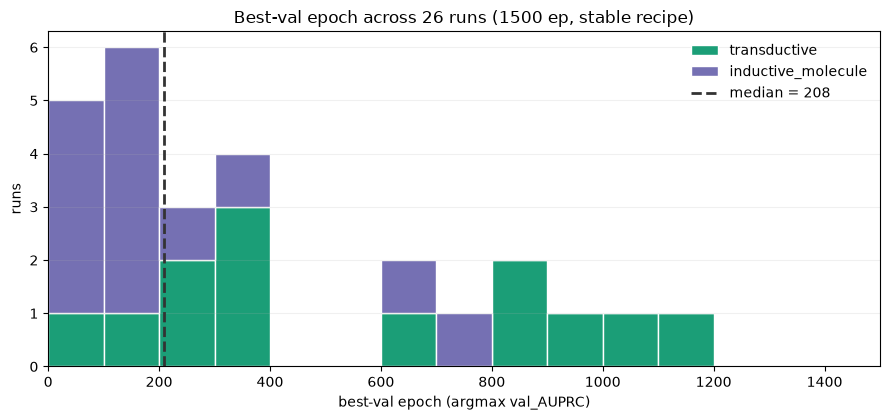

median  transductive=367  inductive=122  overall=208  |  range 11–1163


In [17]:
# Best-val epoch (argmax val_AUPRC) per 1500-epoch run, grouped by regime.
BEST_DIRS = [ROOT / "results/graph/full_full/legacy/pre_v5/rerun_v3/full_full/history",
             ROOT / "results/graph/full_full/legacy/pre_v5/sweep_v3/full_full/history"]
by_regime = {"transductive": [], "inductive_molecule": []}
for d in BEST_DIRS:
    for csv in sorted(d.glob("*_fold1.csv")):
        f = pd.read_csv(csv)
        if len(f) < 1000:
            continue
        best_ep = int(f.loc[f["val_AUPRC"].idxmax(), "epoch"])
        regime = "inductive_molecule" if "inductive_molecule" in csv.stem else "transductive"
        by_regime[regime].append(best_ep)

all_best = np.array(by_regime["transductive"] + by_regime["inductive_molecule"])
REGIME_C = {"transductive": "#1B9E77", "inductive_molecule": "#7570B3"}  # CVD-safe (validated)

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist([by_regime["transductive"], by_regime["inductive_molecule"]],
        bins=range(0, 1600, 100), stacked=True,
        color=[REGIME_C["transductive"], REGIME_C["inductive_molecule"]],
        edgecolor="white", label=["transductive", "inductive_molecule"])
ax.axvline(np.median(all_best), color="#333", lw=2, ls="--",
           label=f"median = {int(np.median(all_best))}")
ax.set_xlabel("best-val epoch (argmax val_AUPRC)"); ax.set_ylabel("runs")
ax.set_title(f"Best-val epoch across {len(all_best)} runs (1500 ep, stable recipe)")
ax.set_xlim(0, 1500); ax.grid(alpha=.18, axis="y"); ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_best_epoch_hist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"median  transductive={int(np.median(by_regime['transductive']))}  "
      f"inductive={int(np.median(by_regime['inductive_molecule']))}  "
      f"overall={int(np.median(all_best))}  |  range {all_best.min()}–{all_best.max()}")

## v4 run — multi-checkpoint diagnostics

Latest run: **gnn · signed · shared · transductive**, 1500 epochs, `--detailed-diagnostics`
(`results/graph/full_full/legacy/pre_v5/v4`, via `scripts/modeling/train/train_graph_v4.py`). It keeps **13 checkpoints**
— 10 periodic (every 150 ep) + `best_auprc` + `best_loss` + `last` — and probes each with an XGBoost
head, recording **train / val / test** metrics. History logs both `train_loss` and `val_loss`.

What to read:
- **`val_loss` (BCE) diverges** (→ ~22) while `train_loss` → 0.1 and val ranking (AUPRC/AUROC) stays
  flat — classic logit explosion: overconfident wrong logits blow up BCE without hurting ranking. So
  **`best_loss` lands at ep 10** and is the *worst* checkpoint — val loss is a bad selector here.
- **The downstream probe is ~flat across checkpoints** after ~ep 300 (test AUPRC ≈ 0.65, AUROC ≈ 0.81):
  more epochs barely move it; `best_auprc` (ep 208) and `last` (ep 1500) are typical, `best_loss` lowest.
- `train_AUPRC` ≈ 1.0 is the boost overfitting its own fit set (expected for a "train" metric).

13 checkpoints: ['ep0150', 'ep0300', 'ep0450', 'ep0600', 'ep0750', 'ep0900', 'ep1050', 'ep1200', 'ep1350', 'ep1500', 'best_auprc', 'best_loss', 'last']
special epochs: {'best_auprc': 208, 'best_loss': 10, 'last': 1500}


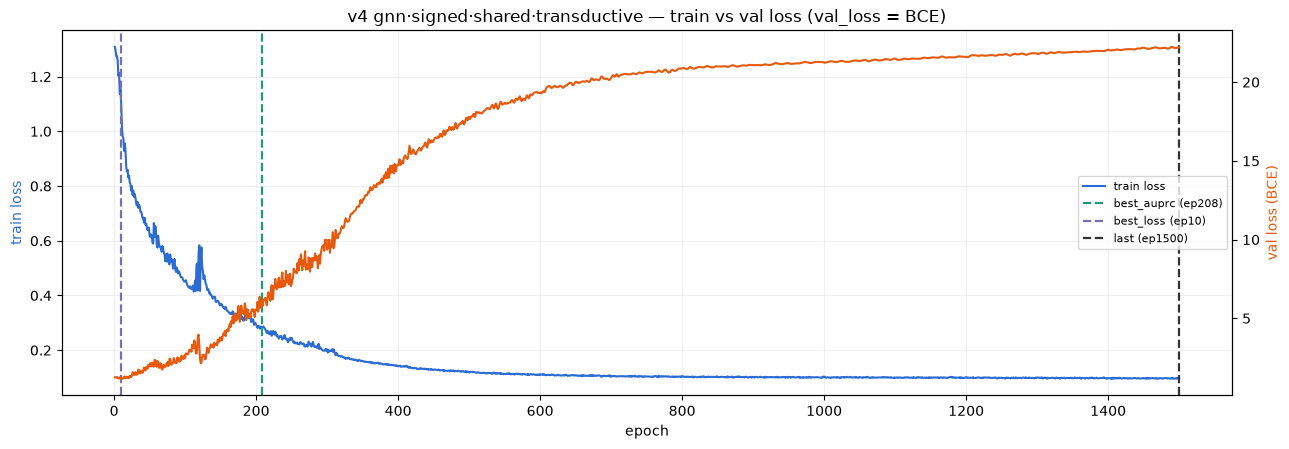

In [18]:
import torch
# Load the v4 multi-checkpoint run.
V4_CKPT = ROOT / "results/graph/full_full/legacy/pre_v5/v4/full_full/checkpoints/gnn_signed_shared_transductive_fold1.pt"
v4 = torch.load(V4_CKPT, map_location="cpu", weights_only=False)
v4_hist = pd.DataFrame(v4["history"])
v4_ck = v4["checkpoints"]
v4_special = {t: v4_ck[t]["epoch"] for t in ("best_auprc", "best_loss", "last")}
print(f"{len(v4['checkpoint_tags'])} checkpoints:", v4["checkpoint_tags"])
print("special epochs:", v4_special)

# --- train vs val loss, with the three special-checkpoint epochs marked ---
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(v4_hist["epoch"], v4_hist["train_loss"], color="#2B6CD4", lw=1.5, label="train loss")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss", color="#2B6CD4"); ax.grid(alpha=.18)
ax2 = ax.twinx()
ax2.plot(v4_hist["epoch"], v4_hist["val_loss"], color="#E8590C", lw=1.5)
ax2.set_ylabel("val loss (BCE)", color="#E8590C")
CMARK = {"best_auprc": "#1B9E77", "best_loss": "#7570B3", "last": "#333333"}
for t, e in v4_special.items():
    ax.axvline(e, color=CMARK[t], ls="--", lw=1.6, label=f"{t} (ep{e})")
ax.set_title("v4 gnn·signed·shared·transductive — train vs val loss (val_loss = BCE)")
ax.legend(fontsize=8, loc="center right")
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_v4_losses.png", dpi=150, bbox_inches="tight")
plt.show()

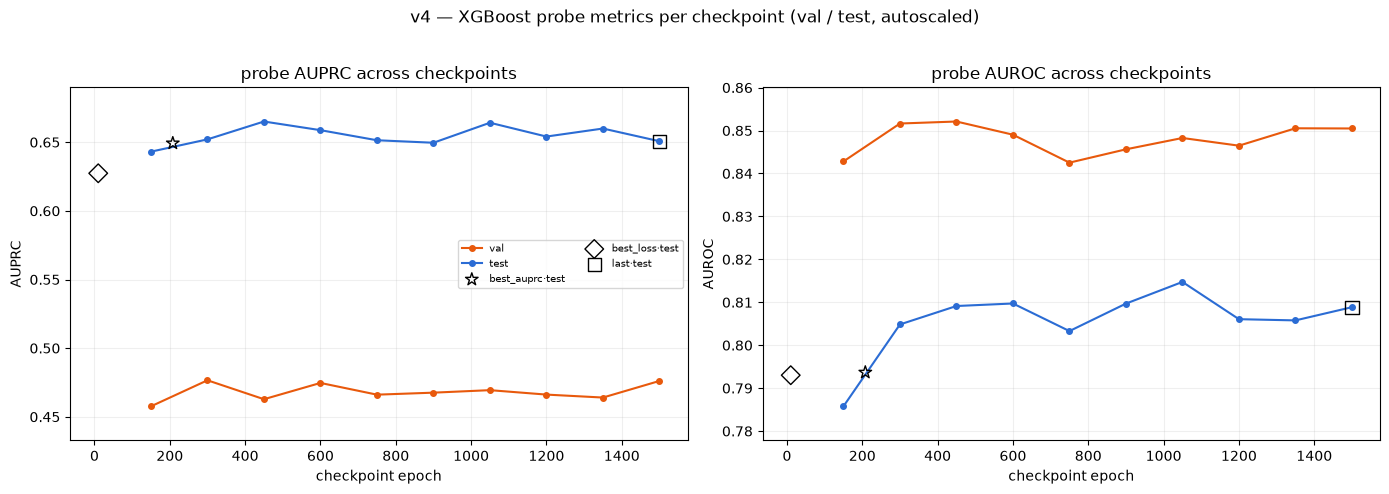

,epoch,train_AUPRC,val_AUPRC,test_AUPRC,test_AUROC,test_MCC,test_F1
tag,,,,,,,
ep0150,150,0.996,0.458,0.643,0.786,0.595,0.674
ep0300,300,0.996,0.477,0.652,0.805,0.613,0.691
ep0450,450,0.997,0.463,0.665,0.809,0.598,0.677
ep0600,600,0.997,0.475,0.659,0.810,0.594,0.676
ep0750,750,0.997,0.466,0.651,0.803,0.616,0.691
ep0900,900,0.997,0.468,0.650,0.810,0.616,0.692
ep1050,1050,0.997,0.469,0.664,0.815,0.598,0.677
ep1200,1200,0.997,0.466,0.654,0.806,0.608,0.686
ep1350,1350,0.997,0.464,0.660,0.806,0.596,0.675


In [19]:
# --- XGBoost probe metrics across all 13 checkpoints (val / test; train dropped) ---
# train sits at ~1.0 (boost overfits its fit set) and flattens the scale, so we plot
# only val/test and autoscale each panel to make the up/down dynamics visible.
per = sorted([t for t in v4["checkpoint_tags"] if t.startswith("ep")],
             key=lambda t: v4_ck[t]["epoch"])
xe = [v4_ck[t]["epoch"] for t in per]
SPL = {"val": "#E8590C", "test": "#2B6CD4"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric in zip(axes, ["AUPRC", "AUROC"]):
    vals = []
    for split in ["val", "test"]:
        ys = [v4_ck[t]["metrics"][split][metric] for t in per]
        vals += ys
        ax.plot(xe, ys, "-o", ms=4, color=SPL[split], label=split)
    for t, mk in [("best_auprc", "*"), ("best_loss", "D"), ("last", "s")]:
        yv = v4_ck[t]["metrics"]["test"][metric]
        vals.append(yv)
        ax.scatter([v4_ck[t]["epoch"]], [yv], marker=mk, s=90,
                   edgecolor="black", facecolor="none", zorder=5, label=f"{t}·test")
    lo, hi = min(vals), max(vals)
    pad = (hi - lo) * 0.12 or 0.01
    ax.set_ylim(lo - pad, hi + pad)                 # autoscale to val/test range
    ax.set_title(f"probe {metric} across checkpoints"); ax.set_xlabel("checkpoint epoch")
    ax.set_ylabel(metric); ax.grid(alpha=.2)
axes[0].legend(fontsize=7, ncol=2, loc="best")
fig.suptitle("v4 — XGBoost probe metrics per checkpoint (val / test, autoscaled)", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_v4_probe_by_ckpt.png", dpi=150, bbox_inches="tight")
plt.show()

# Full table of all 13 checkpoints (train column kept for reference).
rows = []
for t in v4["checkpoint_tags"]:
    e = v4_ck[t]; m = e["metrics"]
    rows.append({"tag": t, "epoch": e["epoch"],
                 "train_AUPRC": m["train"]["AUPRC"], "val_AUPRC": m["val"]["AUPRC"],
                 "test_AUPRC": m["test"]["AUPRC"], "test_AUROC": m["test"]["AUROC"],
                 "test_MCC": m["test"]["MCC"], "test_F1": m["test"]["F1"]})
display(pd.DataFrame(rows).set_index("tag").round(3))

## v4 — inductive_molecule (cold-start molecules)

Same v4 protocol as above, but the **inductive_molecule** regime: whole molecules held out (59 test /
29 val cold mols of 296 testable), so the probe is scored on molecules never seen at train time. This is
the regime where the graph should *earn its keep* — enriched `z_prot` must carry transferable
receptor signal rather than memorised edges.

Training curves mirror transductive (`val_loss` BCE explodes → ~152 while `train_loss` → 0.13, val
ranking plateaus, best val AUROC/AUPRC is early ~ep 50). The question is whether the **downstream probe**
across checkpoints behaves differently from the flat transductive case.

13 checkpoints: ['ep0150', 'ep0300', 'ep0450', 'ep0600', 'ep0750', 'ep0900', 'ep1050', 'ep1200', 'ep1350', 'ep1500', 'best_auprc', 'best_loss', 'last']
special epochs: {'best_auprc': 55, 'best_loss': 4, 'last': 1500}


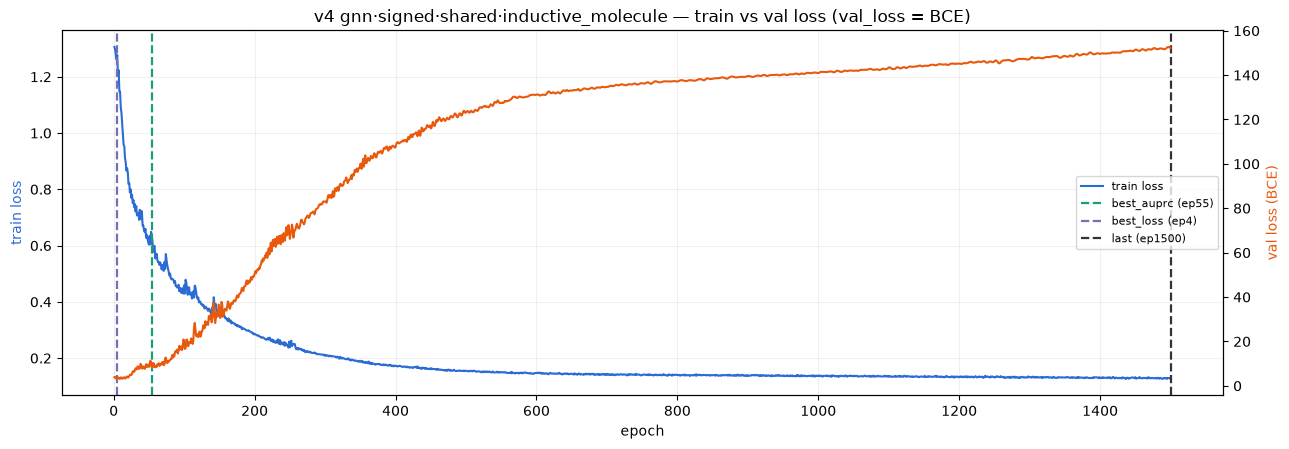

In [20]:
# --- v4 inductive: load + train/val loss with special-checkpoint epochs ---
V4I_CKPT = ROOT / "results/graph/full_full/legacy/pre_v5/v4/full_full/checkpoints/gnn_signed_shared_inductive_molecule_fold1.pt"
v4i = torch.load(V4I_CKPT, map_location="cpu", weights_only=False)
v4i_hist = pd.DataFrame(v4i["history"])
v4i_ck = v4i["checkpoints"]
v4i_special = {t: v4i_ck[t]["epoch"] for t in ("best_auprc", "best_loss", "last")}
print(f"{len(v4i['checkpoint_tags'])} checkpoints:", v4i["checkpoint_tags"])
print("special epochs:", v4i_special)

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(v4i_hist["epoch"], v4i_hist["train_loss"], color="#2B6CD4", lw=1.5, label="train loss")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss", color="#2B6CD4"); ax.grid(alpha=.18)
ax2 = ax.twinx()
ax2.plot(v4i_hist["epoch"], v4i_hist["val_loss"], color="#E8590C", lw=1.5)
ax2.set_ylabel("val loss (BCE)", color="#E8590C")
CMARK = {"best_auprc": "#1B9E77", "best_loss": "#7570B3", "last": "#333333"}
for t, e in v4i_special.items():
    ax.axvline(e, color=CMARK[t], ls="--", lw=1.6, label=f"{t} (ep{e})")
ax.set_title("v4 gnn·signed·shared·inductive_molecule — train vs val loss (val_loss = BCE)")
ax.legend(fontsize=8, loc="center right")
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_v4i_losses.png", dpi=150, bbox_inches="tight")
plt.show()

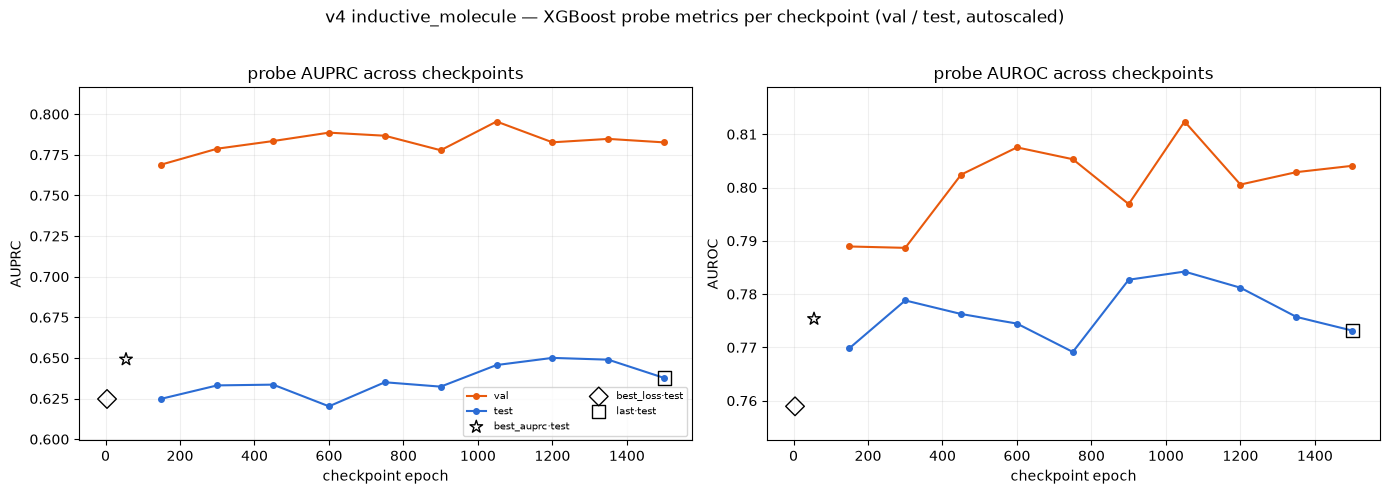

,epoch,train_AUPRC,val_AUPRC,test_AUPRC,test_AUROC,test_MCC,test_F1
tag,,,,,,,
ep0150,150,0.999,0.769,0.625,0.770,0.509,0.579
ep0300,300,1.000,0.779,0.633,0.779,0.491,0.571
ep0450,450,1.000,0.783,0.634,0.776,0.484,0.559
ep0600,600,1.000,0.789,0.620,0.774,0.498,0.569
ep0750,750,1.000,0.787,0.635,0.769,0.512,0.581
ep0900,900,1.000,0.778,0.632,0.783,0.531,0.602
ep1050,1050,1.000,0.795,0.646,0.784,0.541,0.605
ep1200,1200,1.000,0.783,0.650,0.781,0.524,0.589
ep1350,1350,1.000,0.785,0.649,0.776,0.513,0.576


In [21]:
# --- v4 inductive: XGBoost probe metrics across all 13 checkpoints (val / test) ---
peri = sorted([t for t in v4i["checkpoint_tags"] if t.startswith("ep")],
              key=lambda t: v4i_ck[t]["epoch"])
xei = [v4i_ck[t]["epoch"] for t in peri]
SPL = {"val": "#E8590C", "test": "#2B6CD4"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric in zip(axes, ["AUPRC", "AUROC"]):
    vals = []
    for split in ["val", "test"]:
        ys = [v4i_ck[t]["metrics"][split][metric] for t in peri]
        vals += ys
        ax.plot(xei, ys, "-o", ms=4, color=SPL[split], label=split)
    for t, mk in [("best_auprc", "*"), ("best_loss", "D"), ("last", "s")]:
        yv = v4i_ck[t]["metrics"]["test"][metric]
        vals.append(yv)
        ax.scatter([v4i_ck[t]["epoch"]], [yv], marker=mk, s=90,
                   edgecolor="black", facecolor="none", zorder=5, label=f"{t}·test")
    lo, hi = min(vals), max(vals)
    pad = (hi - lo) * 0.12 or 0.01
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(f"probe {metric} across checkpoints"); ax.set_xlabel("checkpoint epoch")
    ax.set_ylabel(metric); ax.grid(alpha=.2)
axes[0].legend(fontsize=7, ncol=2, loc="best")
fig.suptitle("v4 inductive_molecule — XGBoost probe metrics per checkpoint (val / test, autoscaled)", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_v4i_probe_by_ckpt.png", dpi=150, bbox_inches="tight")
plt.show()

rows = []
for t in v4i["checkpoint_tags"]:
    e = v4i_ck[t]; m = e["metrics"]
    rows.append({"tag": t, "epoch": e["epoch"],
                 "train_AUPRC": m["train"]["AUPRC"], "val_AUPRC": m["val"]["AUPRC"],
                 "test_AUPRC": m["test"]["AUPRC"], "test_AUROC": m["test"]["AUROC"],
                 "test_MCC": m["test"]["MCC"], "test_F1": m["test"]["F1"]})
display(pd.DataFrame(rows).set_index("tag").round(3))

In [22]:
# --- transductive vs inductive: test metrics at the three key checkpoints ---
cmp = []
for reg, ck in [("transductive", v4_ck), ("inductive_molecule", v4i_ck)]:
    for t in ("best_auprc", "best_loss", "last"):
        m = ck[t]["metrics"]["test"]
        cmp.append({"regime": reg, "ckpt": t, "epoch": ck[t]["epoch"],
                    "test_AUPRC": m["AUPRC"], "test_AUROC": m["AUROC"],
                    "test_MCC": m["MCC"], "test_F1": m["F1"]})
display(pd.DataFrame(cmp).set_index(["regime", "ckpt"]).round(3))

epoch  test_AUPRC  test_AUROC  test_MCC  \
regime             ckpt                                                  
transductive       best_auprc    208       0.649       0.794     0.599   
                   best_loss      10       0.627       0.793     0.574   
                   last         1500       0.651       0.809     0.604   
inductive_molecule best_auprc     55       0.649       0.775     0.535   
                   best_loss       4       0.625       0.759     0.515   
                   last         1500       0.638       0.773     0.522   

                               test_F1  
regime             ckpt                 
transductive       best_auprc    0.680  
                   best_loss     0.658  
                   last          0.682  
inductive_molecule best_auprc    0.602  
                   best_loss     0.582  
                   last          0.589

### Linear trend of test metrics over episodic checkpoints

Least-squares fit (`np.polyfit` deg 1) of each **test** metric vs checkpoint epoch, using only the
periodic `ep*` checkpoints (special ones excluded). The slope (Δmetric per 1000 ep) tells whether more
training helps, hurts, or is flat for the downstream probe — for both regimes side by side.

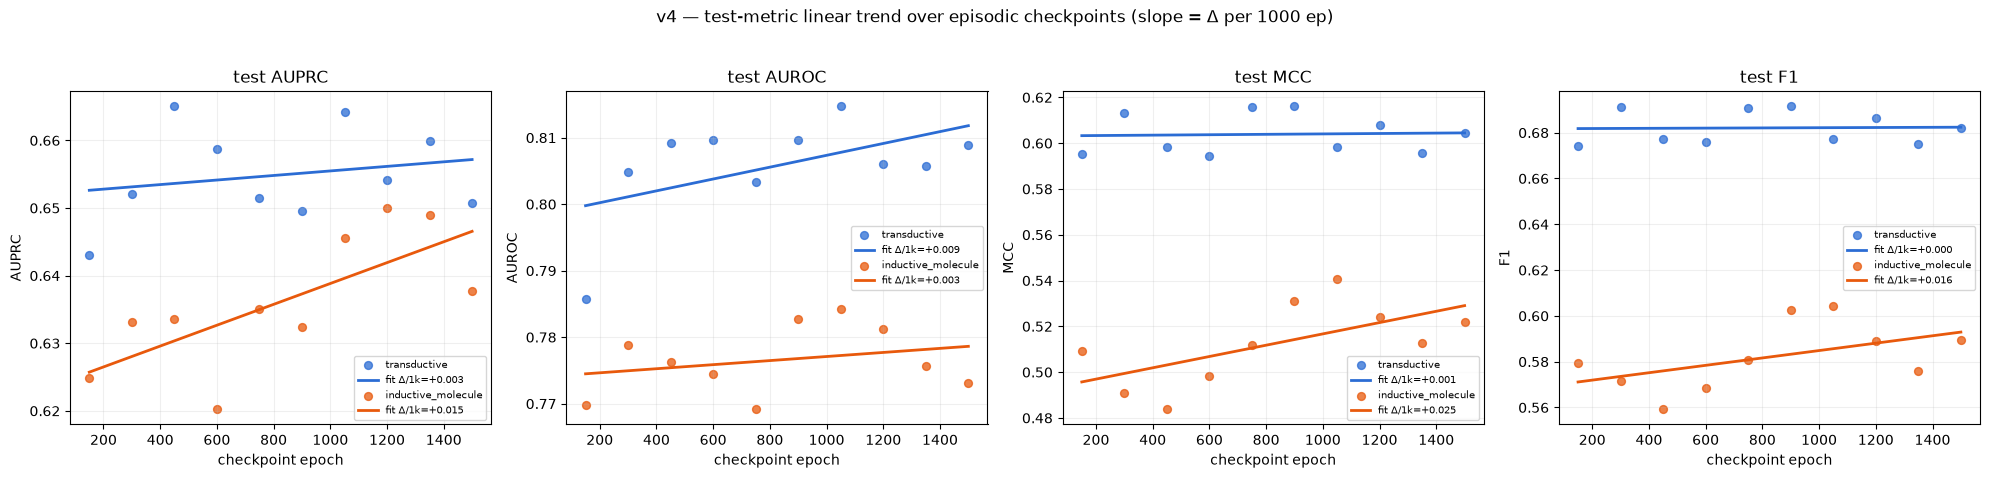

slope_per_1k  intercept  end_fit
metric regime                                              
AUPRC  transductive              0.0034     0.6521   0.6572
       inductive_molecule        0.0154     0.6234   0.6466
AUROC  transductive              0.0089     0.7984   0.8118
       inductive_molecule        0.0031     0.7740   0.7786
MCC    transductive              0.0009     0.6031   0.6045
       inductive_molecule        0.0247     0.4920   0.5291
F1     transductive              0.0004     0.6817   0.6824
       inductive_molecule        0.0161     0.5687   0.5929

In [24]:
# --- linear fits of test metrics across episodic (ep*) checkpoints, both regimes ---
import numpy as np
METRICS = ["AUPRC", "AUROC", "MCC", "F1"]
REG = {"transductive": (v4_ck, "#2B6CD4"), "inductive_molecule": (v4i_ck, "#E8590C")}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
slopes = []
for ax, metric in zip(axes, METRICS):
    for reg, (ck, col) in REG.items():
        per = sorted([t for t in ck if t.startswith("ep")],
                     key=lambda t: ck[t]["epoch"])
        x = np.array([ck[t]["epoch"] for t in per], float)
        y = np.array([ck[t]["metrics"]["test"][metric] for t in per], float)
        b, a = np.polyfit(x, y, 1)          # y = b*x + a
        slope_k = b * 1000                    # per 1000 epochs
        slopes.append({"regime": reg, "metric": metric, "slope_per_1k": slope_k,
                       "intercept": a, "end_fit": b*x[-1]+a})
        ax.scatter(x, y, s=32, color=col, alpha=.75, label=f"{reg}")
        ax.plot(x, b*x + a, color=col, lw=2,
                label=f"fit Δ/1k={slope_k:+.3f}")
    ax.set_title(f"test {metric}"); ax.set_xlabel("checkpoint epoch")
    ax.set_ylabel(metric); ax.grid(alpha=.2); ax.legend(fontsize=7)
fig.suptitle("v4 — test-metric linear trend over episodic checkpoints (slope = Δ per 1000 ep)", y=1.03)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/diag_v4_test_slopes.png", dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame(slopes).set_index(["metric", "regime"]).round(4))